# use this code to scrab data from the archieved aaclmp dataset and then putting them into CSV file

In [ ]:
import pyprind
import pandas as pd
import os
import sys

basepath = 'aclImdb'

labels = {'pos': 1, 'neg' : 0}

pbar = pyprind.ProgBar(50000, stream = sys.stdout)
df = pd.DataFrame()
row = []
for s in ('test', 'train'):
    for l in ('pos', 'neg'):
        path  = os.path.join(basepath, s,l)

        for file in sorted(os.listdir(path)):
            with open(os.path.join(path, file),'r', encoding= 'utf-8') as infile:
                txt = infile.read()
                #row.append([txt, ])
                #row.append([[txt, labels[l]]])
                row.append({'review': txt, 'sentiment': labels[l]})

                pbar.update()

 
df  = pd.DataFrame(row, columns= ['review', 'sentiment'])

import numpy as np

np.random.seed(0)

df = df.reindex(np.random.permutation(df.index))

df.to_csv('movie_data.csv', index=False, encoding='utf-8')

In [1]:
import numpy as np

import pyprind
import pandas as pd
import os
import sys

df = pd.read_csv('movie_data.csv', encoding= 'utf-8')

df = df.rename(columns={"0": "review", "1": "sentiment"})
df.head(3)


,review,sentiment
0,"Election is a Chinese mob movie, or triads in ...",1
1,I was just watching a Forensic Files marathon ...,0
2,Police Story is a stunning series of set piece...,1


# Transforming words into feature vectors Through CountVectorizer 


N-gram models
      The sequence of items in the bag-of-words model that we just created is also called the 1-gram or unigram model—each item or token in the vocabulary represents a single word. More generally, the contiguous sequences of items in NLP—words, letters, or symbols—are also called n-grams. The choice of the number, n, in the n-gram model depends on the particular application; for example, a study by Ioannis Kanaris and others revealed that n-grams of size 3 and 4 yield good performances in the anti-spam filtering of email messages (Words versus character n-grams for anti-spam filtering by Ioannis Kanaris, Konstantinos Kanaris, Ioannis Houvardas, and Efstathios Stamatatos, International Journal on Artificial Intelligence Tools, World Scientific Publishing Company, 16(06): 1047-1067, 2007).
      To summarize the concept of the n-gram representation, the 1-gram and 2-gram representations of our first document, “the sun is shining”, would be constructed as follows:
      
        1-gram: “the”, “sun”, “is”, “shining”
        2-gram: “the sun”, “sun is”, “is shining”
      
      The CountVectorizer class in scikit-learn allows us to use different n-gram models via its ngram_range parameter. While a 1-gram representation is used by default, we could switch to a 2-gram representation by initializing a new CountVectorizer instance with ngram_range=(2,2).

In [2]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

count = CountVectorizer()

docs =  np.array(['The sun is shining', 'the weather is good','The sun is shining the weather is good'  ])


bag = count.fit_transform(docs)

print(count.vocabulary_)

print(bag.toarray())

#Notethe array maps like good appears as index 0 so in the doc 1 it appears 0 btimes


{'the': 4, 'sun': 3, 'is': 1, 'shining': 2, 'weather': 5, 'good': 0}
[[0 1 1 1 1 0]
 [1 1 0 0 1 1]
 [1 2 1 1 2 1]]


# Assessing word relevancy via term frequency-inverse document frequency

 the term frequency-inverse document frequency (tf-idf), which can be used to downweight these frequently occurring words in the feature vectors. The tf-idf can be defined as the product of the term frequency and the inverse document frequency

 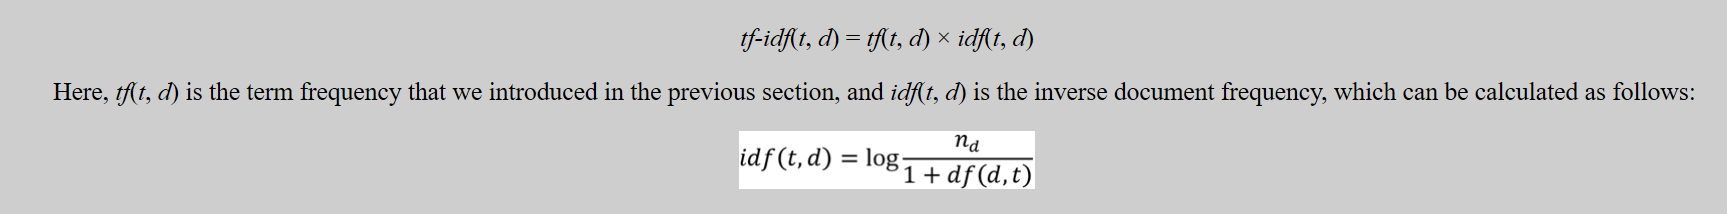
 Here, nd is the total number of documents, and df(d, t) is the number of documents, d, that contain the term t. Note that adding the constant 1 to the denominator is optional and serves the purpose of assigning a non-zero value to terms that occur in none of the training examples; the log is used to ensure that low document frequencies are not given too much weight.
    The scikit-learn library implements yet another transformer, the TfidfTransformer class, which takes the raw term frequencies from the CountVectorizer class as input and transforms them into tf-idfs:

In [3]:
# note the TfidfTransformer class,  takes the raw term frequencies from the CountVectorizer class as input and transforms them into tf-idfs:

from sklearn.feature_extraction.text import TfidfTransformer

tfidf = TfidfTransformer(use_idf=True, norm= 'l2', smooth_idf= True)

np.set_printoptions(precision=2)

print(tfidf.fit_transform(count.fit_transform(docs)).toarray())



[[0.   0.43 0.56 0.56 0.43 0.  ]
 [0.56 0.43 0.   0.   0.43 0.56]
 [0.34 0.52 0.34 0.34 0.52 0.34]]


# Cleaning data

In [4]:
import re

def preprocess(text):
    text =  re.sub('<[^>]*>', '', text)
    emoticoins =  re.findall('(?::|;|=)(?:-)?(?:\)|\(|D|P)',text)

    test = (re.sub('[\W]+', ' ', text.lower() + ' '.join(emoticoins).replace('_', '')))

    return text
            

<>:5: SyntaxWarning: invalid escape sequence '\)'
<>:7: SyntaxWarning: invalid escape sequence '\W'
<>:5: SyntaxWarning: invalid escape sequence '\)'
<>:7: SyntaxWarning: invalid escape sequence '\W'
C:\Users\Aron\AppData\Local\Temp\ipykernel_25456\3246210612.py:5: SyntaxWarning: invalid escape sequence '\)'
  emoticoins =  re.findall('(?::|;|=)(?:-)?(?:\)|\(|D|P)',text)
C:\Users\Aron\AppData\Local\Temp\ipykernel_25456\3246210612.py:7: SyntaxWarning: invalid escape sequence '\W'
  test = (re.sub('[\W]+', ' ', text.lower() + ' '.join(emoticoins).replace('_', '')))


In [5]:
preprocess(df.loc[0,'review'][-50:])
preprocess("</a> This :) is : (a test :-)!")

' This :) is : (a test :-)!'

In [6]:
df['review'] = df['review'].apply(preprocess)

# Preprocessing documents into tokens

In [7]:
def tokenixer(text):
    return text.split()
tokenixer("Hello good morning, I noticed runnners like running in marathon run")

['Hello',
 'good',
 'morning,',
 'I',
 'noticed',
 'runnners',
 'like',
 'running',
 'in',
 'marathon',
 'run']

# Using Porter stemming algorithm
A word stemming, is the process of transforming a word into its root form

In [8]:
from nltk.stem.porter import PorterStemmer

porter = PorterStemmer()

def tokenixer_ported(text):
    return [porter.stem(word) for word in text.split()]

tokenixer_ported("Hello good morning, I noticed runnners like running in marathon run")
# it reduces the running to its root form run

['hello',
 'good',
 'morning,',
 'i',
 'notic',
 'runnner',
 'like',
 'run',
 'in',
 'marathon',
 'run']

# Note lematization is process of making sense out of data and has low impacvt on text classification also the stemming

# STOP WORD REMOVAL

In [9]:
import sys
import nltk
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

In [10]:
from nltk.corpus import stopwords

stop = stopwords.words('english')
[w for w in tokenixer_ported("Hello good morning, I noticed runnners like running in marathon run") if w not in stop ]

['hello',
 'good',
 'morning,',
 'notic',
 'runnner',
 'like',
 'run',
 'marathon',
 'run']

# Training  Logistic Regrssion for document classification

In [11]:
X_train = df.loc[:25000,'review'].values
y_train = df.loc[:25000, 'sentiment'].values
X_test = df.loc[25000:, 'review'].values
Y_test = df.loc[25000:, 'sentiment'].values

In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model  import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

tfid = TfidfVectorizer(strip_accents=None, lowercase= False, preprocessor= None)

# Note the TfidfVectorizer combines both thr countervectorizer and tdidf transformer

small_grd = [{'vect__ngram_range': [(1,1)],
              'vect__stop_words': [None],
              'vect__tokenizer': [tokenixer, tokenixer_ported],
              'clf__penalty': ['l2'],
              'clf__C': [1.0,10.0]},
              {
                  'vect__ngram_range': [(1,1)],
                  'vect__stop_words': [stop, None],
                  'vect__tokenizer':[tokenixer],
                  'vect__use_idf': [False],
                  'vect__norm': [None],
                  'clf__penalty': ['l2'],
                  'clf__C': [1.0,10.0], 

              },]

lr_tfid = Pipeline([('vect', tfid), ('clf', LogisticRegression(solver = "liblinear"))])

grdvce_tfid = GridSearchCV(lr_tfid, small_grd, scoring = 'accuracy', verbose = 2, cv =5, n_jobs=-1)

grdvce_tfid.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


c:\Users\Aron\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('vect',
                                        TfidfVectorizer(lowercase=False)),
                                       ('clf',
                                        LogisticRegression(solver='liblinear'))]),
             n_jobs=-1,
             param_grid=[{'clf__C': [1.0, 10.0], 'clf__penalty': ['l2'],
                          'vect__ngram_range': [(1, 1)],
                          'vect__stop_words': [None],
                          'vect__tokenizer': [<function tokenixer at 0x00000202D3ADBD80>,
                                              <function tokenixer_ported at 0x00000202...
                          'vect__stop_words': [['a', 'about', 'above', 'after',
                                                'again', 'against', 'ain',
                                                'all', 'am', 'an', 'and', 'any',
                                                'are', 'aren', "aren't", 'as',
                                                'at', 'be', 'because', 'been',
                                                'before', 'being', 'below',
                                                'between', 'both', 'but', 'by',
                                                'can', 'couldn', "couldn't", ...],
                                               None],
                          'vect__tokenizer': [<function tokenixer at 0x00000202D3ADBD80>],
                          'vect__use_idf': [False]}],
             scoring='accuracy', verbose=2)

In [21]:
print(f'Best parameter set: {grdvce_tfid.best_params_}')
print(f'CV Accuracy: {grdvce_tfid.best_score_:.3f}')

Best parameter set: {'clf__C': 10.0, 'clf__penalty': 'l2', 'vect__ngram_range': (1, 1), 'vect__stop_words': None, 'vect__tokenizer': <function tokenixer at 0x00000202D3ADBD80>}
CV Accuracy: 0.889
